# Log or Simple — a quantitative teardown \U0001F52C
### Jensen · the σ²/2 expansion and its residual · terminal-wealth cost · Sharpe vs beta sensitivity

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Useful](https://img.shields.io/badge/Usefulness-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Unusually for
this desk there is nothing to *test* here — the results are identities — so the study is about
**magnitudes** and about the one place the identity becomes a bug that ships.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance, pinned as-of the date
> in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from log_vs_simple import data, strategy as st

px = data.load_prices()
print(f"as-of {data.AS_OF}")
for tk in data.TICKERS:
    s = px[tk].dropna()
    v = s.pct_change().std() * np.sqrt(252)
    print(f"  {tk:8s} {s.index[0].date()} -> {s.index[-1].date()}  "
          f"n={len(s):6,}  annualised vol {v:6.1%}")

as-of 2026-06-30
  BIL      2007-05-30 -> 2026-06-30  n= 4,802  annualised vol   0.5%
  TLT      2002-07-30 -> 2026-06-30  n= 6,018  annualised vol  14.3%
  SPY      1993-01-29 -> 2026-06-30  n= 8,411  annualised vol  18.6%
  QQQ      1999-03-10 -> 2026-06-30  n= 6,869  annualised vol  27.0%
  EEM      2003-04-14 -> 2026-06-30  n= 5,840  annualised vol  27.1%
  GLD      2004-11-18 -> 2026-06-30  n= 5,436  annualised vol  18.2%
  TQQQ     2010-02-11 -> 2026-06-30  n= 4,120  annualised vol  61.2%
  BTC-USD  2014-09-17 -> 2026-06-30  n= 4,305  annualised vol  55.3%


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | It scales with the square of volatility, so it is invisible at one end of the tape and enormous at the other. On **BIL** (0% annualised vol) the mean simple and mean log returns differ by **0.00%/yr**; on **TQQQ** (61% vol) they differ by **18.9%/yr**, and the sigma-squared-over-two prediction accounts for 99% of it. The Sharpe ratio moves too: up to **0.31** between the two conventions. |
| **Usefulness** | Useful | Yes, and it is two lines. **Across time, use logs** (they add, and their mean exponentiates to the CAGR the path delivered). **Across assets, use simple returns** (a portfolio's return is a weighted average of them, exactly). The failure mode is weighting log returns: on an equal-weight book of 7 tapes it understated the CAGR by **6.11%/yr** — 1.80x of terminal wealth over 12 years — and it understated on **essentially every day**, because Jensen's inequality only points one way. |

> \U0001F4A1 **In plain words.** Two conventions, one rule each, and one bug that silently
> costs you the rebalancing bonus.

## 1 · The claim, stated as identities

- **I₁.** `sum_t r_t = ln(P_T/P_0)` exactly. Log returns aggregate across time.
- **I₂.** `R_p = sum_i w_i R_i` exactly. Simple returns aggregate across assets.
- **I₃.** `E[ln(1+R)] = E[R] - Var(R)/2 + E[R³]/3 - ...` — the drag, with the terms nobody
  quotes made explicit.
- **I₄.** `ln(sum_i w_i (1+R_i)) ≥ sum_i w_i ln(1+R_i)` (Jensen). The portfolio mistake is a
  one-sided error, with equality only when all assets move identically.

## 2 · So what? — the quantitative stakes

I₄ is the interesting one, because it is a *bug pattern*: it produces a plausible-looking
number that is always too low, on every day, forever, and nothing in a test suite catches it
unless someone thought to compare against the compounded simple path.

## 3 · How we'd know — the protocol

Nothing to estimate; everything to measure. The tapes span 0.3% to 65% annualised volatility on
purpose, because the effect is quadratic in exactly that number. The σ²/2 approximation is
scored against the *realised* gap so its own error is visible rather than assumed away.

## 4 · The teardown

### 4.1 The expansion, and what it misses

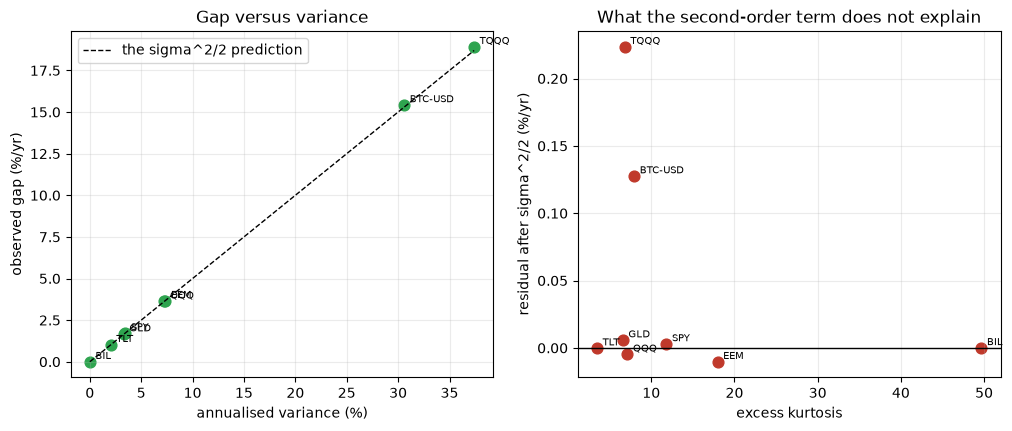

,vol_ann,gap_ann,half_var_ann,residual_ann,skew,excess_kurtosis
ticker,,,,,,
BIL,0.0049,0.0000,0.0000,0.0000,-0.1408,49.6763
TLT,0.1430,0.0102,0.0102,-0.0000,0.0539,3.4890
GLD,0.1818,0.0166,0.0165,0.0001,-0.3125,6.5810
SPY,0.1858,0.0173,0.0173,0.0000,-0.0116,11.8226
QQQ,0.2695,0.0363,0.0363,-0.0000,0.2251,7.1332
EEM,0.2712,0.0367,0.0368,-0.0001,0.4756,17.9660
BTC-USD,0.5531,0.1542,0.1530,0.0013,-0.0956,7.9497
TQQQ,0.6115,0.1892,0.1870,0.0022,-0.2270,6.8261


In [3]:
dt = st.drag_table(px).sort_values("vol_ann")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(dt["vol_ann"] ** 2 * 100, dt["gap_ann"] * 100, s=60, color="#2ea44f")
lim = np.linspace(0, (dt["vol_ann"] ** 2).max() * 100, 20)
axes[0].plot(lim, lim / 2, color="k", ls="--", lw=1, label="the sigma^2/2 prediction")
for tk, r in dt.iterrows():
    axes[0].annotate(tk, (r["vol_ann"] ** 2 * 100, r["gap_ann"] * 100), fontsize=7,
                     xytext=(4, 2), textcoords="offset points")
axes[0].set_xlabel("annualised variance (%)"); axes[0].set_ylabel("observed gap (%/yr)")
axes[0].legend(); axes[0].set_title("Gap versus variance")
axes[1].scatter(dt["excess_kurtosis"], dt["residual_ann"] * 100, s=60, color="#c0392b")
for tk, r in dt.iterrows():
    axes[1].annotate(tk, (r["excess_kurtosis"], r["residual_ann"] * 100), fontsize=7,
                     xytext=(4, 2), textcoords="offset points")
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel("excess kurtosis"); axes[1].set_ylabel("residual after sigma^2/2 (%/yr)")
axes[1].set_title("What the second-order term does not explain")
plt.show()
dt[["vol_ann", "gap_ann", "half_var_ann", "residual_ann", "skew", "excess_kurtosis"]].round(4)

> \U0001F4A1 **In plain words.** The textbook formula is a two-term Taylor expansion. On a
> tape with fat tails, the terms it drops are not negligible — the residual column is the size
> of the mistake made by people who quote σ²/2 as if it were exact.

### 4.2 Jensen, measured

daily gap (bps): mean +1.98, median +0.84, min +0.00, max +99.40
share of days where the log-weighted version is lower: 100.0000%


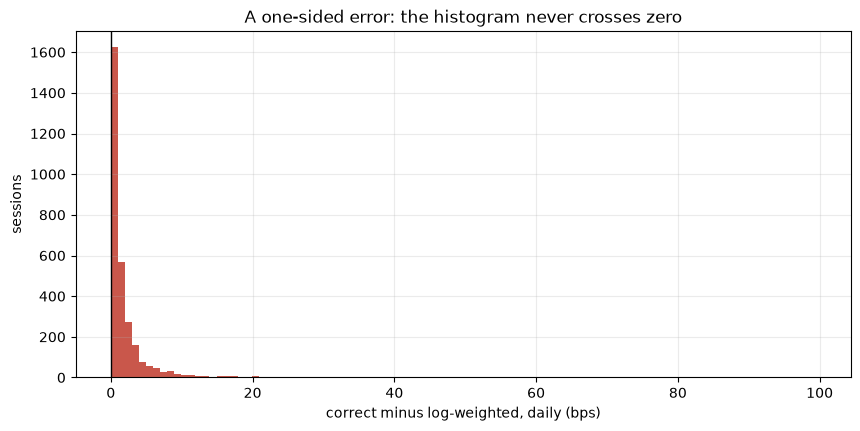

In [4]:
universe = tuple(tk for tk in data.TICKERS if tk != "BIL")
sub = px[list(universe)].dropna()
R = sub.pct_change().dropna()
L = np.log(sub / sub.shift(1)).dropna()
w = np.full(len(universe), 1 / len(universe))
diff = (st.portfolio_simple(R, w) - np.expm1(st.portfolio_from_logs(L, w))) * 1e4
print(f"daily gap (bps): mean {diff.mean():+.2f}, median {diff.median():+.2f}, "
      f"min {diff.min():+.2f}, max {diff.max():+.2f}")
print(f"share of days where the log-weighted version is lower: {(diff >= -1e-9).mean():.4%}")
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(diff, bins=100, color="#c0392b", alpha=0.85)
ax.axvline(0, color="k", lw=1)
ax.set_xlabel("correct minus log-weighted, daily (bps)"); ax.set_ylabel("sessions")
ax.set_title("A one-sided error: the histogram never crosses zero")
plt.show()

### 4.3 The error IS the rebalancing bonus

In [5]:
err = st.portfolio_error(px, universe)
bonus = st.rebalancing_bonus(px, universe)
print(f"log-weighting error : {err['cagr_gap']:+.3%}/yr")
print(f"rebalancing bonus   : {bonus['bonus']:+.3%}/yr")
print(f"  rebalanced CAGR {bonus['rebalanced_cagr']:+.2%} vs average buy-and-hold "
      f"{bonus['buy_hold_avg_cagr']:+.2%}")
print()
print(pd.Series(bonus["per_asset_cagr"], name="buy-and-hold CAGR by asset").round(4).to_string())

log-weighting error : +6.114%/yr
rebalancing bonus   : +6.114%/yr
  rebalanced CAGR +24.96% vs average buy-and-hold +19.98%

TLT       0.0049
SPY       0.1376
QQQ       0.1948
EEM       0.0624
GLD       0.1021
TQQQ      0.3860
BTC-USD   0.5111


### 4.4 How the error scales with the dispersion of the book

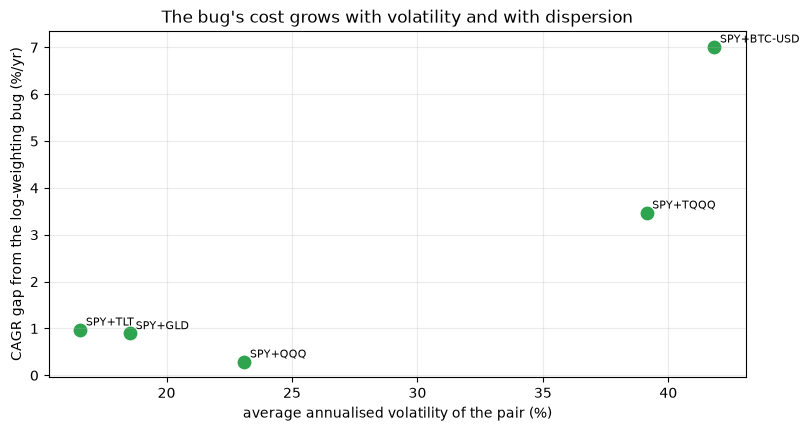

,cagr_gap,avg vol,correlation,years
pair,,,,
SPY+TLT,0.0097,0.1656,-0.3034,23.8770
SPY+GLD,0.0090,0.1855,0.0642,21.5675
SPY+QQQ,0.0029,0.2310,0.8527,27.2540
SPY+TQQQ,0.0347,0.3914,0.9303,16.3452
SPY+BTC-USD,0.0701,0.4184,0.2253,11.7540


In [6]:
rows = []
for tk in ("TLT", "GLD", "QQQ", "TQQQ", "BTC-USD"):
    e = st.portfolio_error(px, ("SPY", tk))
    pair = px[["SPY", tk]].dropna().pct_change().dropna()
    rows.append({"pair": f"SPY+{tk}", "cagr_gap": e["cagr_gap"],
                 "avg vol": pair.std().mean() * np.sqrt(252),
                 "correlation": pair.corr().iloc[0, 1], "years": e["years"]})
d = pd.DataFrame(rows).set_index("pair")
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(d["avg vol"] * 100, d["cagr_gap"] * 100, s=80, color="#2ea44f")
for name, r in d.iterrows():
    ax.annotate(name, (r["avg vol"] * 100, r["cagr_gap"] * 100), fontsize=8,
                xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("average annualised volatility of the pair (%)")
ax.set_ylabel("CAGR gap from the log-weighting bug (%/yr)")
ax.set_title("The bug's cost grows with volatility and with dispersion")
plt.show()
d.round(4)

### 4.5 Sharpe moves; beta does not

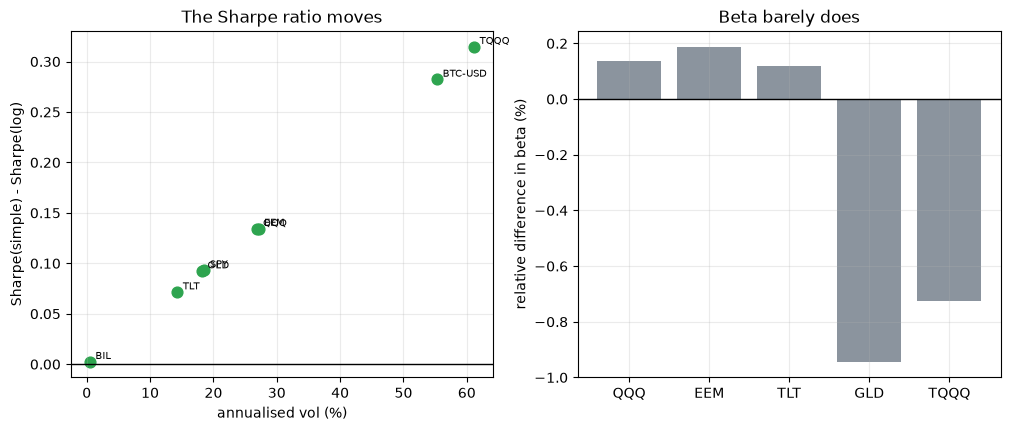

         sharpe_simple  sharpe_log    gap  relative_gap  vol_ann
ticker                                                          
BIL             2.7721      2.7696 0.0024        0.0009   0.0049
TLT             0.3282      0.2568 0.0714        0.2176   0.1430
GLD             0.6309      0.5386 0.0923        0.1462   0.1818
SPY             0.6468      0.5535 0.0933        0.1442   0.1858
QQQ             0.5212      0.3871 0.1341        0.2573   0.2695
EEM             0.4935      0.3591 0.1345        0.2725   0.2712
BTC-USD         0.7925      0.5103 0.2822        0.3561   0.5531
TQQQ            0.9073      0.5926 0.3147        0.3468   0.6115

        beta_simple  beta_log     gap  relative_gap     n
ticker                                                   
QQQ          1.1934    1.1917  0.0016        0.0014  6868
EEM          1.1889    1.1867  0.0022        0.0019  5839
TLT         -0.2304   -0.2301 -0.0003        0.0012  6017
GLD          0.0617    0.0623 -0.0006       -0.0094  5435
T

In [7]:
sg = st.sharpe_gap(px).sort_values("vol_ann")
betas = pd.DataFrame([dict(ticker=tk, **st.beta_gap(px, tk, "SPY"))
                      for tk in ("QQQ", "EEM", "TLT", "GLD", "TQQQ")]).set_index("ticker")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(sg["vol_ann"] * 100, sg["gap"], s=60, color="#2ea44f")
for tk, r in sg.iterrows():
    axes[0].annotate(tk, (r["vol_ann"] * 100, r["gap"]), fontsize=7, xytext=(4, 2),
                     textcoords="offset points")
axes[0].axhline(0, color="k", lw=1); axes[0].set_xlabel("annualised vol (%)")
axes[0].set_ylabel("Sharpe(simple) - Sharpe(log)"); axes[0].set_title("The Sharpe ratio moves")
axes[1].bar(betas.index, betas["relative_gap"] * 100, color="#8b949e")
axes[1].axhline(0, color="k", lw=1)
axes[1].set_ylabel("relative difference in beta (%)"); axes[1].set_title("Beta barely does")
plt.show()
print(sg.round(4).to_string())
print()
print(betas.round(4).to_string())

> \U0001F4A1 **In plain words.** Beta survives the convention change because it is a ratio in
> which the second-order corrections appear in both the numerator and the denominator and
> largely cancel. Sharpe does not, because the drag hits the numerator only.

## 5 · The verdict

In [8]:
summary = pd.DataFrame({
    "largest mean gap (%/yr)": [dt["gap_ann"].max() * 100],
    "on": [dt["gap_ann"].idxmax()],
    "largest Sharpe gap": [sg["gap"].abs().max()],
    "portfolio bug (%/yr)": [err["cagr_gap"] * 100],
    "terminal wealth ratio": [err["terminal_ratio"]],
    "one-sided?": [err["always_understates"]],
}).T.rename(columns={0: "value"})
summary

,value
largest mean gap (%/yr),18.9215
on,TQQQ
largest Sharpe gap,0.3147
portfolio bug (%/yr),6.1136
terminal wealth ratio,1.8033
one-sided?,True


## 6 · The rule, restated as code review

```python
# WRONG — log returns are not linear across assets
port = (log_rets * weights).sum(axis=1)

# RIGHT
port = (simple_rets * weights).sum(axis=1)
# and if you then need to compound it through time:
log_port = np.log1p(port)
```

## 7 · Going further

- **Continuous-time**: Fernholz's excess growth rate derives the same gap from stochastic
  portfolio theory, and generalises it to non-equal weights.
- **Higher moments**: the residual column in 4.1 is a Cornish-Fisher expansion waiting to
  happen.
- **Currency and leverage** stack the same second-order term twice; studies 995 and 942-944 on
  this desk are the two directions.